<a href="https://colab.research.google.com/github/Udaybhan2023/Stock-Market-Price-Prediction-Nifty-50-using-Machine-Learning-Deep-Learning/blob/main/stock_market_price_priduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import library**

In [ ]:
#Install mplfinance if not already installed
try:
    import mplfinance as mpf
except ModuleNotFoundError:
    !pip install mplfinance
    import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import math
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.9 MB/s eta 0:00:00


**DATA COLLECTION**

```
# This is formatted as code
```



In [ ]:
# step 1: DATA COLLECTION Stock Market Prediction - Nifty 50 till date
ticker = '^NSEI'
data = yf.download(ticker, start='2019-01-01', end='2026-05-01')
print(data.isnull().sum())
print(data.duplicated().sum())
data.reset_index(inplace=True)
print(f'Dataset Shape: {data.shape}')
print(data.head())
print(data.tail())
print(data.info())
print(data.describe())

[*********************100%***********************]  1 of 1 completed

Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64
0
Dataset Shape: (1806, 6)
Price        Date         Close          High           Low          Open  \
Ticker                    ^NSEI         ^NSEI         ^NSEI         ^NSEI   
0      2019-01-02  10792.500000  10895.349609  10735.049805  10868.849609   
1      2019-01-03  10672.250000  10814.049805  10661.250000  10796.799805   
2      2019-01-04  10727.349609  10741.049805  10628.650391  10699.700195   
3      2019-01-07  10771.799805  10835.950195  10750.150391  10804.849609   
4      2019-01-08  10802.150391  10818.450195  10733.250000  10786.250000   

Price   Volume  
Ticker   ^NSEI  
0       309700  
1       286200  
2       296600  
3       269400  
4       277700  
Price        Date         Close          High           Low          Open  \
Ticker                    ^NSEI         ^NSEI         ^NSEI         ^NSEI   
1801   2026-04-24  23897.949219 

DATA  PREPROCESSING

In [ ]:
# Flatten MultiIndex-like columns if they exist
# The columns are likely tuples like ('Date', ) or ('Close', '^NSEI')
# The 'ticker' variable is available from the kernel state, which is '^NSEI'.
if any(isinstance(col, tuple) for col in data.columns):
    new_columns = []
    for col in data.columns:
        if isinstance(col, tuple):
            # Handle ('Date', ) as 'Date'
            if len(col) == 2 and col[0] == 'Date' and col[1] == '':
                new_columns.append(col[0])
            # Handle ('Close', '^NSEI') as 'Close' and similar columns
            elif len(col) == 2 and col[1] == ticker:
                new_columns.append(col[0])
            # Fallback for other tuple columns
            else:
                new_columns.append('_'.join(map(str, col)))
        else:
            new_columns.append(col)
    data.columns = new_columns

data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

rows_before_outlier_removal = data.shape[0]

Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
data = data[(data['Close'] >= lower_limit) & (data['Close'] <= upper_limit)]

print(f"Shape of DataFrame after outlier removal: {data.shape}")

print(f"Removed {rows_before_outlier_removal - data.shape[0]} rows containing Close price outliers.")

Shape of DataFrame after outlier removal: (1806, 6)
Removed 0 rows containing Close price outliers.


### Creating Lag Features for MACD,RSI, BB_Upper & BB_Lower  

In [ ]:
def add_technical_indicators(data):
    # Simple Moving Averages
    data['SMA_10']  = data['Close'].rolling(window=10).mean()
    data['SMA_20']  = data['Close'].rolling(window=20).mean()
    data['SMA_50']  = data['Close'].rolling(window=50).mean()

    # Exponential Moving Averages
    data['EMA_12']  = data['Close'].ewm(span=12, adjust=False).mean()
    data['EMA_26']  = data['Close'].ewm(span=26, adjust=False).mean()

    # MACD
    data['MACD']    = data['EMA_12'] - data['EMA_26']
    data['Signal']  = data['MACD'].ewm(span=9, adjust=False).mean()

    # RSI (14-day)
    delta = data['Close'].diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs    = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    # Bollinger Bands
    data['BB_Mid']   = data['Close'].rolling(20).mean()
    data['BB_Std']   = data['Close'].rolling(20).std()
    data['BB_Upper'] = data['BB_Mid'] + 2 * data['BB_Std']
    data['BB_Lower'] = data['BB_Mid'] - 2 * data['BB_Std']

    # Lag features
    data['MA10'] = data['Close'].rolling(10).mean()
    data['MA50'] = data['Close'].rolling(50).mean()
    data['Lag1'] = data['Close'].shift(1)
    data['Lag2'] = data['Close'].shift(2)
    data['Return'] = data['Close'].pct_change()
    data["lag1"] = data["Close"].shift(1)
    data["std5"] = data["Close"].rolling(5).std()

    # Average True Range
    data['TR']  = np.maximum(data['High'] - data['Low'],
                np.maximum(abs(data['High'] - data['Close'].shift(1)),
                           abs(data['Low']  - data['Close'].shift(1))))
    data['ATR'] = data['TR'].rolling(14).mean()

    # On-Balance Volume
    data['OBV'] = (np.sign(data['Close'].diff()) * data['Volume']).fillna(0).cumsum()

    # Daily Return
    data['Daily_Return'] = data['Close'].pct_change()

    return data.dropna()

data = add_technical_indicators(data)
print(f'Shape after feature engineering: {data.shape}')
print(data[['Date','Close','SMA_20','RSI','MACD','BB_Upper','BB_Lower','MA10','MA50','Lag1','Lag2']].tail(5))

Shape after feature engineering: (1757, 29)
           Date         Close        SMA_20        RSI       MACD  \
1801 2026-04-24  23897.949219  23634.604980  67.064645  91.217849   
1802 2026-04-27  24092.699219  23693.619922  66.481484  88.858143   
1803 2026-04-28  23995.699219  23728.082422  63.004592  78.258850   
1804 2026-04-29  24177.650391  23795.984961  53.387710  83.577346   
1805 2026-04-30  23997.550781  23879.292480  54.246951  72.424890   

          BB_Upper      BB_Lower          MA10          MA50          Lag1  \
1801  25037.443859  22231.766102  24206.540039  24283.630039  24173.050781   
1802  25067.543306  22319.696538  24210.750000  24248.138008  23897.949219   
1803  25095.677963  22360.486880  24226.054883  24209.348984  24092.699219   
1804  25107.357378  22484.612544  24220.689844  24173.825000  23995.699219   
1805  24996.184940  22762.400021  24200.769922  24137.632031  24177.650391   

              Lag2  
1801  24378.099609  
1802  24173.050781  
1803  238

### Visualizing Engineered Features

In [ ]:
feature_cols = ['Open','High','Low','Volume','SMA_10','SMA_20','SMA_50',
                'EMA_12','EMA_26','MACD','Signal','RSI',
                'BB_Upper','BB_Lower','MA10','MA50','Lag1','Lag2','ATR','OBV','Daily_Return']

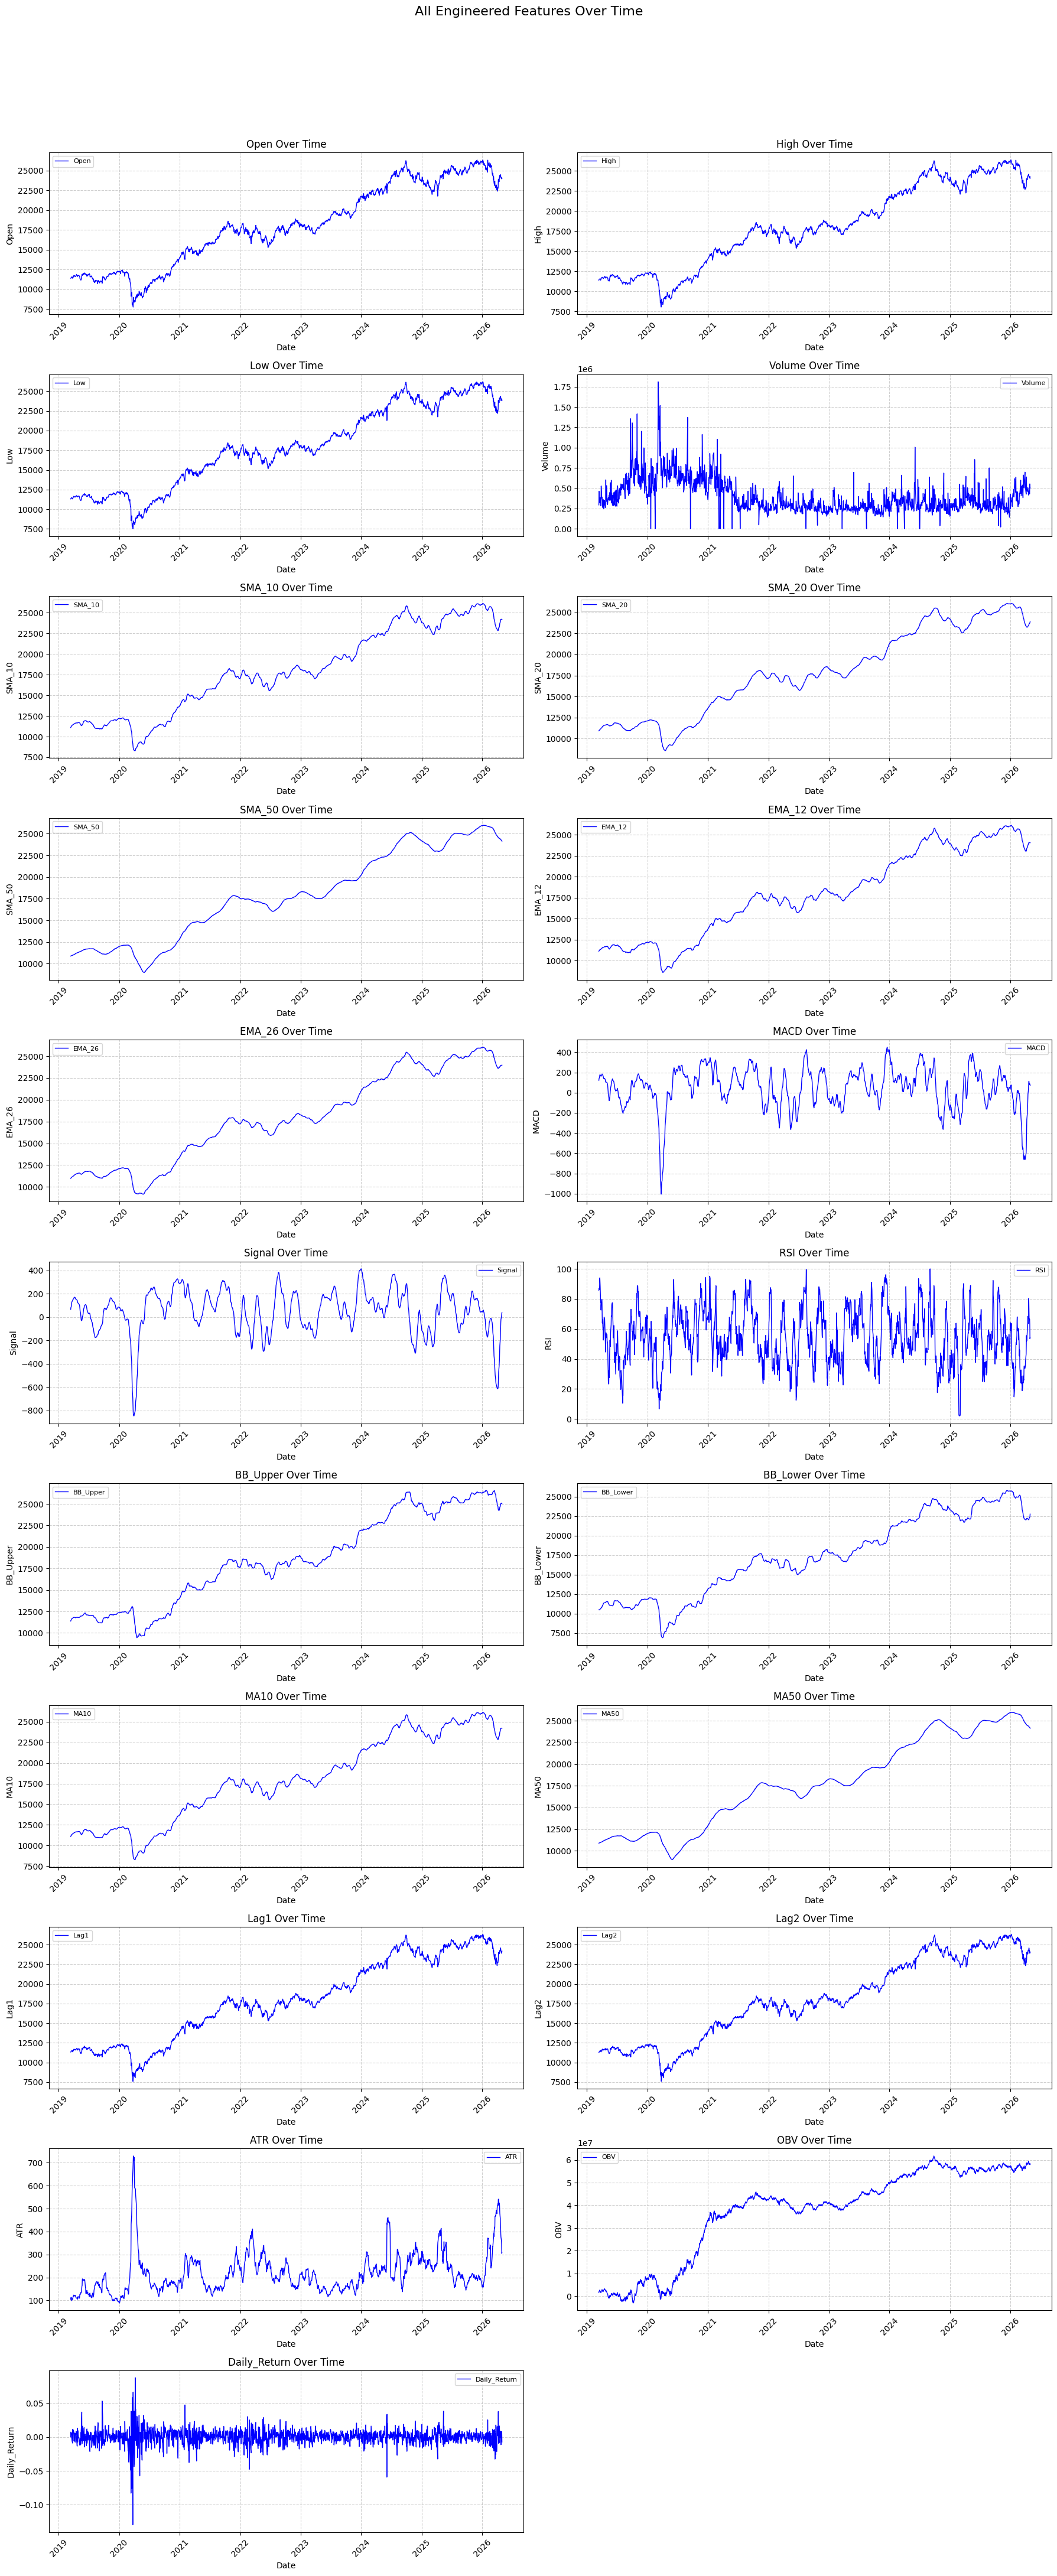

In [ ]:
feature_cols = ['Open','High','Low','Volume','SMA_10','SMA_20','SMA_50',
                'EMA_12','EMA_26','MACD','Signal','RSI',
                'BB_Upper','BB_Lower','MA10','MA50','Lag1','Lag2','ATR','OBV','Daily_Return']

num_features = len(feature_cols)
num_rows = (num_features + 1) // 2  # Arrange in 2 columns

fig, axes = plt.subplots(num_rows, 2, figsize=(18, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature in enumerate(feature_cols):
    axes[i].plot(data['Date'], data[feature], label=feature, color='blue', linewidth=1)
    axes[i].set_title(f'{feature} Over Time', fontsize=12)
    axes[i].set_xlabel('Date', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots if the number of features is odd
if num_features < len(axes):
    for i in range(num_features, len(axes)):
        fig.delaxes(axes[i])

plt.suptitle('All Engineered Features Over Time', fontsize=16, y=1.02) # Adjusted y to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

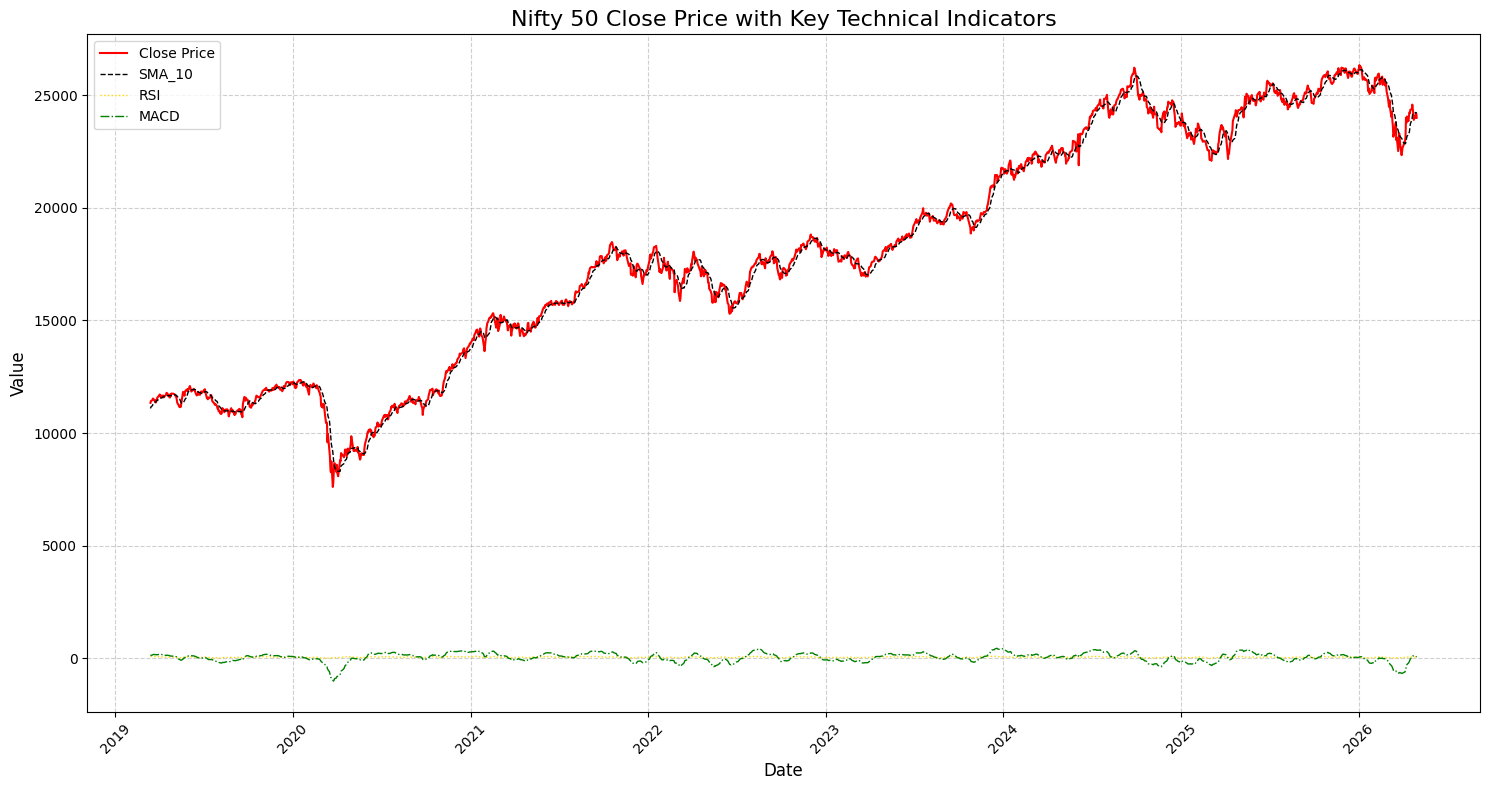

In [ ]:
plt.figure(figsize=(15, 8))

# Plotting Close price
plt.plot(data['Date'], data['Close'], label='Close Price', color='red', linewidth=1.5)

# Plotting SMA_10
plt.plot(data['Date'], data['SMA_10'], label='SMA_10', color='black', linestyle='--', linewidth=1)

# Plotting RSI
plt.plot(data['Date'], data['RSI'], label='RSI', color='gold', linestyle=':', linewidth=1)

# Plotting MACD
plt.plot(data['Date'], data['MACD'], label='MACD', color='green', linestyle='-.', linewidth=1)

plt.title('Nifty 50 Close Price with Key Technical Indicators', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

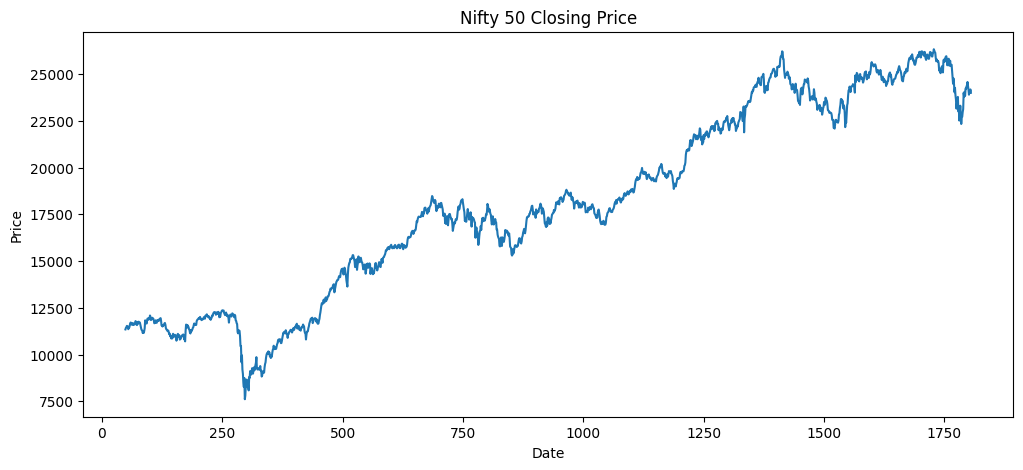

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("Nifty 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Weekly Candlestick Chart

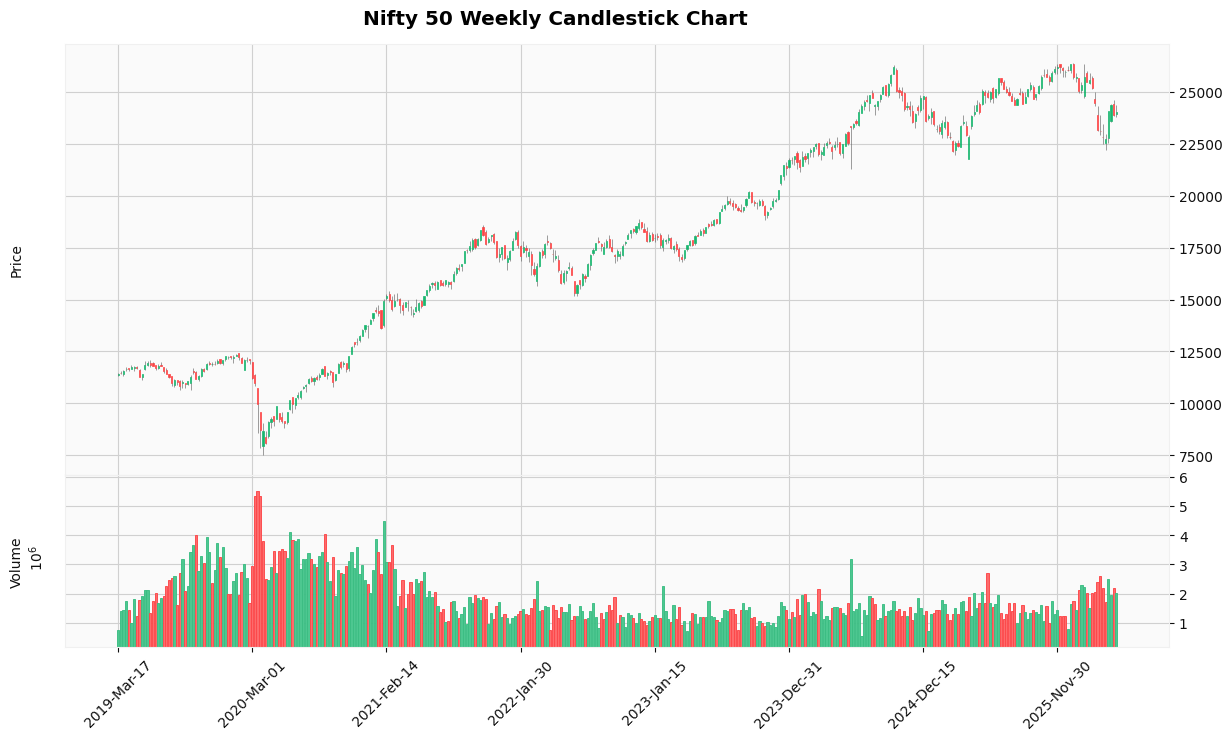

In [ ]:
# Prepare data for plotting
# The original 'data' DataFrame needs to have 'Date' as index for resampling and mpf.plot
data_plot = data.copy()
data_plot['Date'] = pd.to_datetime(data_plot['Date'])
data_plot.set_index('Date', inplace=True)

# Resample to Weekly
data_weekly = data_plot.resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

fig, axes = mpf.plot(data_weekly, type='candle', style='yahoo',
                     title='Nifty 50 Weekly Candlestick Chart',
                     ylabel='Price',
                     volume=True, ylabel_lower='Volume',
                     show_nontrading=False,
                     figscale=1.5,
                     figratio=(16,9),
                     returnfig=True)

fig.suptitle('Nifty 50 Weekly Candlestick Chart', y=0.92)

for ax in axes:
    if isinstance(ax, plt.Axes):
        ax.yaxis.set_label_coords(-0.05, 0.5)

plt.tight_layout()
plt.show()

### Monthly Candlestick Chart

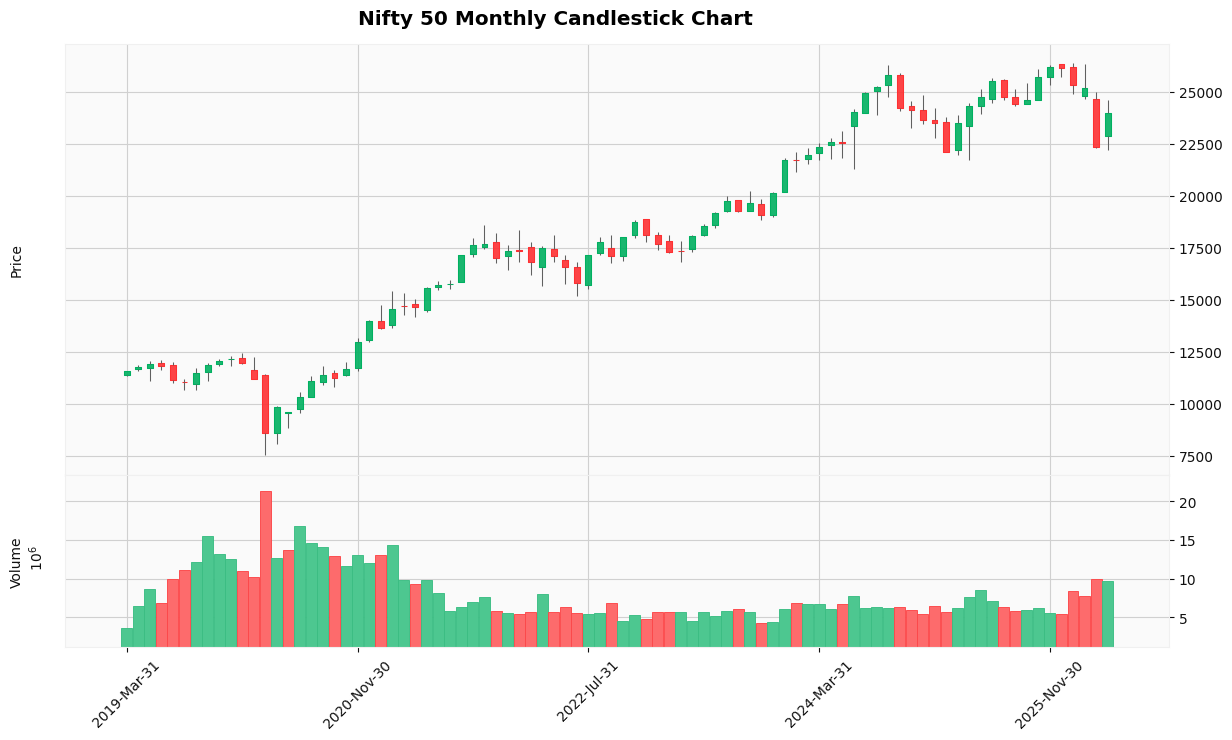

In [ ]:
# Prepare data for plotting
# The original 'data' DataFrame needs to have 'Date' as index for resampling and mpf.plot
df_plot = data.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])
df_plot.set_index('Date', inplace=True)

# Resample to Monthly
# Fix: Changed frequency from 'M' to 'ME' as per pandas 2.2.0+ requirements
df_monthly = df_plot.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

fig, axes = mpf.plot(df_monthly, type='candle', style='yahoo',
                     title='Nifty 50 Monthly Candlestick Chart',
                     ylabel='Price',
                     volume=True, ylabel_lower='Volume',
                     show_nontrading=False,
                     figscale=1.5,
                     figratio=(16,9),
                     returnfig=True)

fig.suptitle('Nifty 50 Monthly Candlestick Chart', y=0.92)

for ax in axes:
    if isinstance(ax, plt.Axes):
        ax.yaxis.set_label_coords(-0.05, 0.5)

plt.tight_layout()
plt.show()

### Quarterly Candlestick Chart

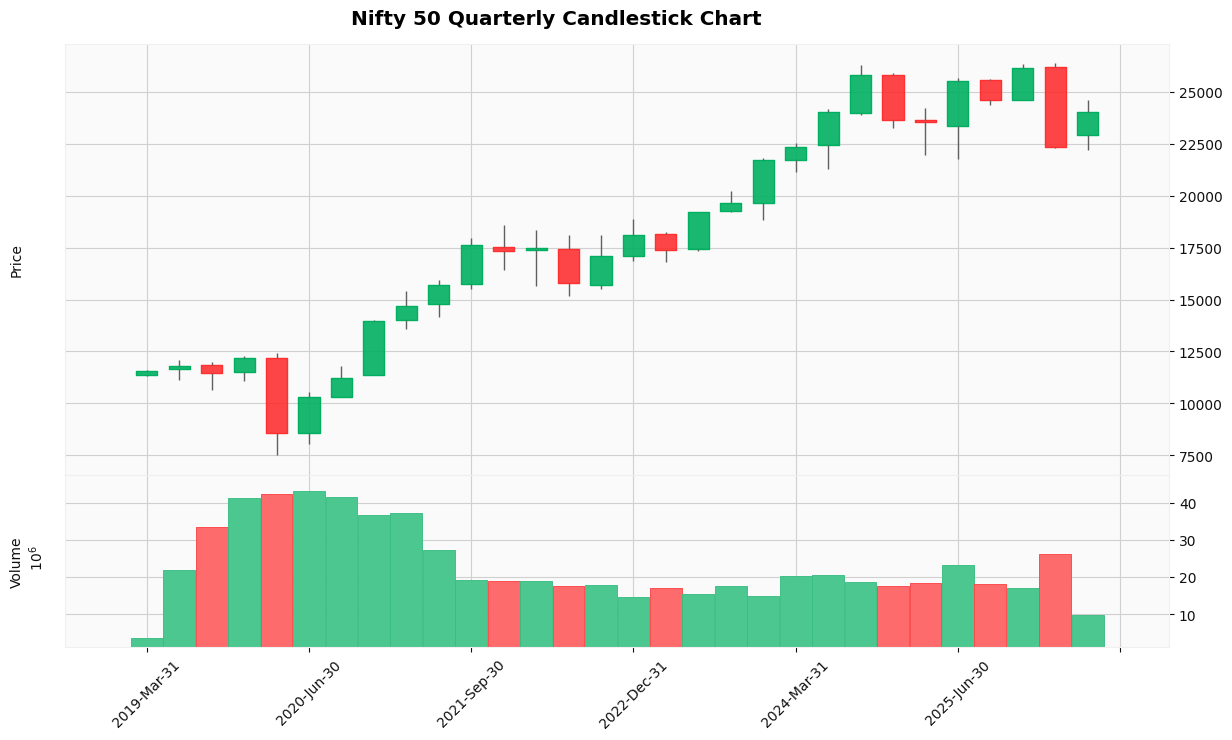

In [ ]:
# Resample to Quarterly
# Fix: Changed frequency from 'Q' to 'QE' as per pandas 2.2.0+ requirements
df_quarterly = df_plot.resample('QE').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

fig, axes = mpf.plot(df_quarterly, type='candle', style='yahoo',
                     title='Nifty 50 Quarterly Candlestick Chart',
                     ylabel='Price',
                     volume=True, ylabel_lower='Volume',
                     show_nontrading=False,
                     figscale=1.5,
                     figratio=(16,9),
                     returnfig=True)

fig.suptitle('Nifty 50 Quarterly Candlestick Chart', y=0.92)

for ax in axes:
    if isinstance(ax, plt.Axes):
        ax.yaxis.set_label_coords(-0.05, 0.5)

plt.tight_layout()
plt.show()

                 Close      High       Low      Open    Volume    SMA_10  \
Close         1.000000  0.999825  0.999828  0.999623 -0.524439  0.998311   
High          0.999825  1.000000  0.999738  0.999852 -0.520780  0.998687   
Low           0.999828  0.999738  1.000000  0.999784 -0.528074  0.998198   
Open          0.999623  0.999852  0.999784  1.000000 -0.523713  0.998507   
Volume       -0.524439 -0.520780 -0.528074 -0.523713  1.000000 -0.520307   
SMA_10        0.998311  0.998687  0.998198  0.998507 -0.520307  1.000000   
SMA_20        0.996365  0.996897  0.996127  0.996566 -0.517522  0.999004   
SMA_50        0.990553  0.991308  0.990114  0.990756 -0.511322  0.993735   
EMA_12        0.998516  0.998880  0.998384  0.998678 -0.520457  0.999895   
EMA_26        0.996468  0.997009  0.996211  0.996660 -0.517252  0.998836   
MACD          0.077425  0.072882  0.080616  0.076650 -0.095143  0.052120   
Signal        0.081884  0.078570  0.084853  0.081996 -0.089391  0.069486   
RSI         

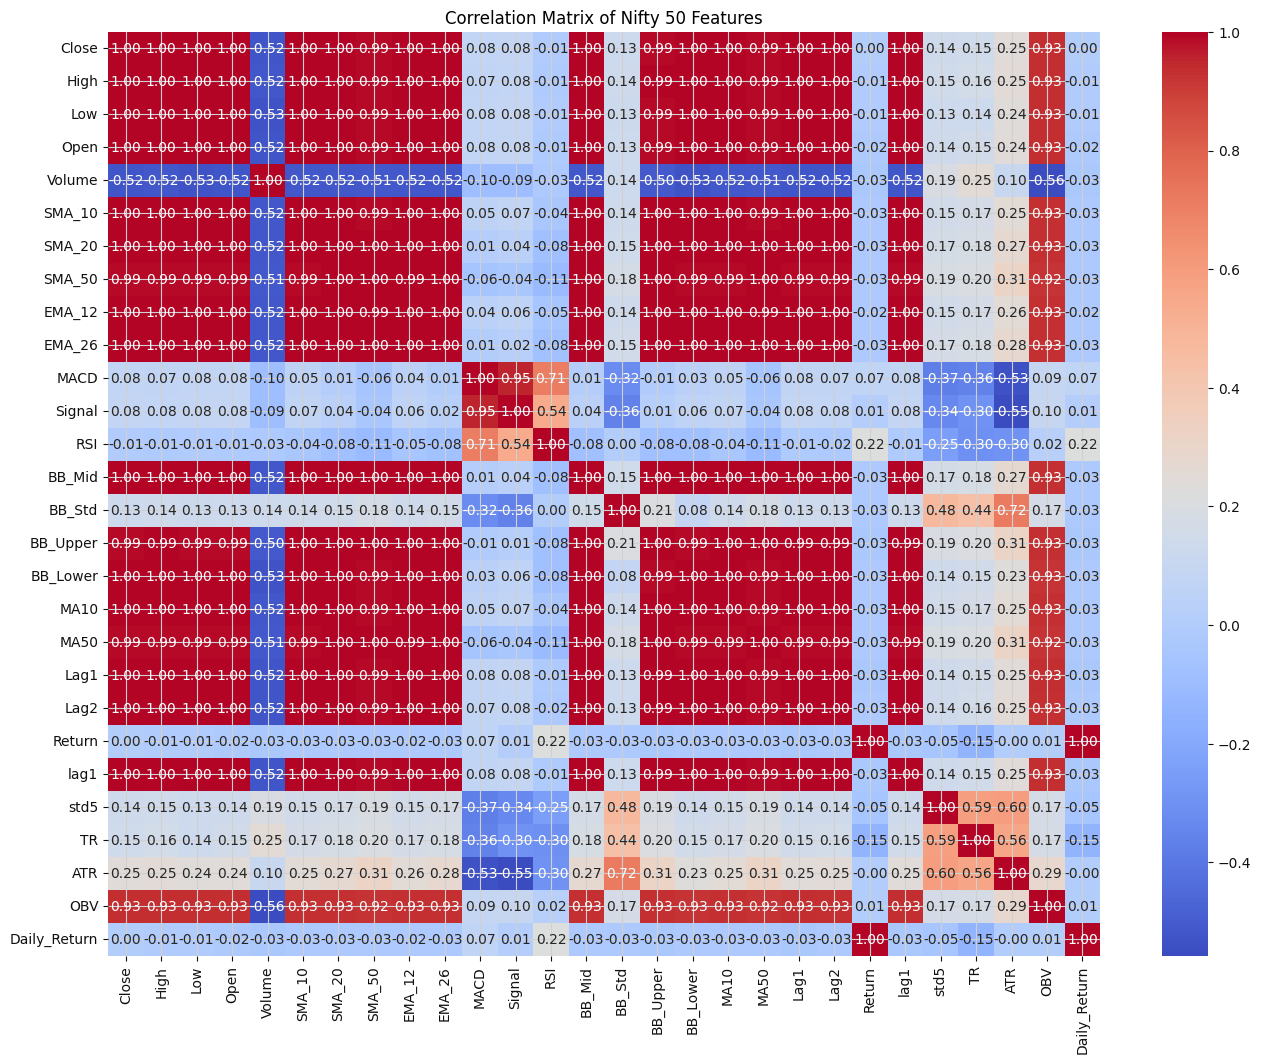

In [ ]:
# Calculate the correlation matrix
correlation_matrix = data.corr(numeric_only=True)

# Display the correlation matrix
print(correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Nifty 50 Features')
plt.show()

### Features Most Correlated with 'Close' Price

In [ ]:
# Get correlations with 'Close' price, excluding 'Close' itself
close_correlations = correlation_matrix['Close'].drop('Close')

# Sort correlations by absolute value to find the strongest ones
sorted_correlations = close_correlations.abs().sort_values(ascending=False)

# Display the top 5 most positively correlated features
print("\nTop 5 Most Positively Correlated Features with Close Price:")
print(close_correlations.loc[sorted_correlations.head(5).index].sort_values(ascending=False))

# Display the top 5 most negatively correlated features
print("\nTop 5 Most Negatively Correlated Features with Close Price:")
print(close_correlations.loc[sorted_correlations.head(5).index].sort_values())



Top 5 Most Positively Correlated Features with Close Price:
Low     0.999828
High    0.999825
Open    0.999623
lag1    0.999405
Lag1    0.999405
Name: Close, dtype: float64

Top 5 Most Negatively Correlated Features with Close Price:
lag1    0.999405
Lag1    0.999405
Open    0.999623
High    0.999825
Low     0.999828
Name: Close, dtype: float64


### Features with Negative Correlation to 'Close' Price

In [ ]:
# Filter for negative correlations with 'Close' price
negative_correlations = close_correlations[close_correlations < 0].sort_values(ascending=True)

# Display these negatively correlated features
if not negative_correlations.empty:
    print("\nFeatures Negatively Correlated with Close Price:")
    print(negative_correlations)
else:
    print("\nNo features found with negative correlation to Close Price.")



Features Negatively Correlated with Close Price:
Volume   -0.524439
RSI      -0.006824
Name: Close, dtype: float64


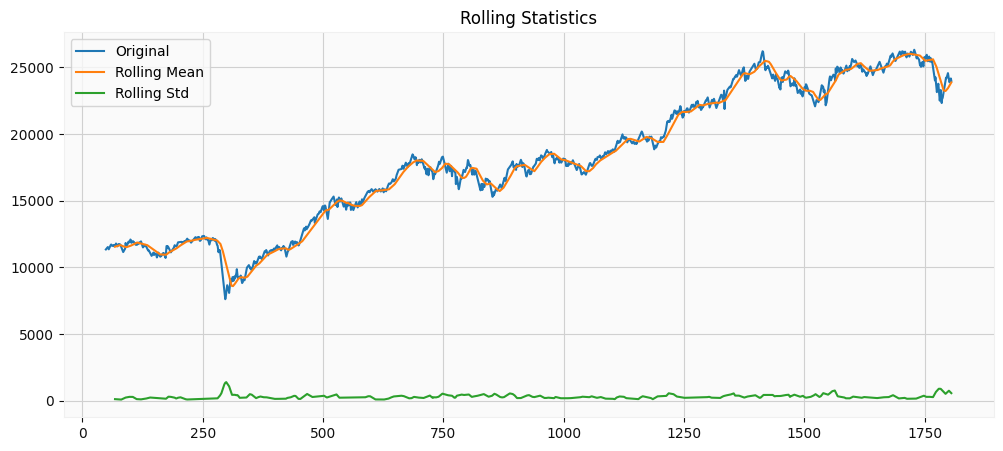

In [ ]:
rolling_mean = data['Close'].rolling(window=20).mean()
rolling_std = data['Close'].rolling(window=20).std()

plt.figure(figsize=(12,5))
plt.plot(data['Close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

#**MACHINE LEARNING MODELS**
# ============================================================

In [ ]:

# -----------------------------------------------------------
# 2.1 Prepare ML Features and Target
# -----------------------------------------------------------
feature_cols = ['Open','High','Low','Volume','SMA_10','SMA_20','SMA_50',
                'EMA_12','EMA_26','MACD','Signal','RSI',
                'BB_Upper','BB_Lower','MA10','MA50','Lag1','Lag2','ATR','OBV','Daily_Return']

X = data[feature_cols].values
y = data['Close'].values

# Train / Test Split (80/20) - chronological
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Scale features
scaler_X = MinMaxScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

In [ ]:
# 2.2 Evaluation Helper
# -----------------------------------------------------------
def evaluate(name, y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f'\n{name}')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  MAPE : {mape:.2f}%')
    print(f'  R2   : {r2:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

results = []

In [ ]:
# 2.3 Linear Regression
# -----------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
results.append(evaluate('Linear Regression', y_test, y_pred_lr))


Linear Regression
  RMSE : 47.42
  MAE  : 36.26
  MAPE : 0.15%
  R2   : 0.9980


In [ ]:
# -----------------------------------------------------------
# 2.4 Random Forest Regressor
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, max_depth=14,
                           random_state=40, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
results.append(evaluate('Random Forest', y_test, y_pred_rf))



Random Forest
  RMSE : 179.35
  MAE  : 129.83
  MAPE : 0.54%
  R2   : 0.9717


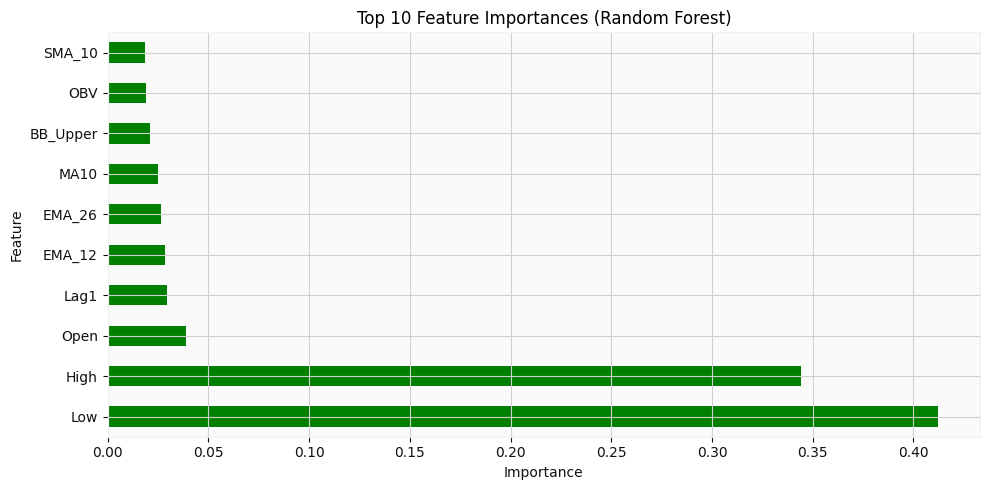

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
rf_feat_imp = pd.Series(rf.feature_importances_, index=feature_cols)

# Sort and plot the top 10 feature importances
rf_feat_imp.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10,5),
    color='green', title='Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 2.5 XGBoost Regressor
# -----------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.04,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.2,
    reg_lambda=2,
    random_state=40
)
xgb.fit(X_train_sc, y_train,
        eval_set=[(X_test_sc, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test_sc)
results.append(evaluate('XGBoost', y_test, y_pred_xgb))


XGBoost
  RMSE : 159.63
  MAE  : 115.42
  MAPE : 0.47%
  R2   : 0.9776


In [ ]:
# -----------------------------------------------------------
# 2.6 Support Vector Regression
# -----------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
svr = SVR(kernel='rbf', C=1500, gamma=0.01, epsilon=0.01)
svr.fit(X_train_sc, y_train)
y_pred_svr = svr.predict(X_test_sc)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
results.append(evaluate('SVR (RBF)', y_test, y_pred_svr))


SVR (RBF)
  RMSE : 221.62
  MAE  : 182.02
  MAPE : 0.74%
  R2   : 0.9568


In [ ]:
# -----------------------------------------------------------
# 2.7 Results Summary Table
# -----------------------------------------------------------
results_df = pd.DataFrame(results)
print('\n===== ML MODEL COMPARISON =====')
print(results_df.sort_values('RMSE').to_string(index=False))



===== ML MODEL COMPARISON =====
            Model       RMSE        MAE     MAPE       R2
Linear Regression  47.420234  36.264360 0.149330 0.998022
          XGBoost 159.633679 115.416110 0.465841 0.977583
    Random Forest 179.352152 129.829345 0.535465 0.971703
        SVR (RBF) 221.621440 182.020730 0.738900 0.956794




# Deep Learning Models (LSTM, GRU, CNN-LSTM)



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout,
    Conv1D, MaxPooling1D, Flatten, BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
# -----------------------------------------------------------
# 3.1 Prepare Sequential Data for DL (Lookback = 60 days) - now with multiple features
# -----------------------------------------------------------
LOOKBACK = 60

# Scale all relevant features for DL
# We'll use the feature_cols we defined for ML models

# First, prepare the data with selected features
data_features = data[feature_cols].copy()

# Scale the features
scaler_features = MinMaxScaler(feature_range=(0, 1))
features_scaled = scaler_features.fit_transform(data_features)

# Also scale the target 'Close' price separately for inverse transformation later
scaler_close_dl = MinMaxScaler(feature_range=(0, 1))
close_scaled_dl = scaler_close_dl.fit_transform(data[['Close']].values)

def create_sequences_multi_feature(data_scaled, target_scaled, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data_scaled)):
        X_seq.append(data_scaled[i-lookback:i, :]) # Use all features for X
        y_seq.append(target_scaled[i, 0]) # Target remains the Close price
    return np.array(X_seq), np.array(y_seq)

# Now, use the multi-feature sequence creation function
X_dl, y_dl = create_sequences_multi_feature(features_scaled, close_scaled_dl, LOOKBACK)

# X_dl is already 3D (samples, lookback, features) due to create_sequences_multi_feature
# We need the number of features for the input shape of the models
n_features = X_dl.shape[2]

split_dl = int(len(X_dl) * 0.80)
X_tr, X_te = X_dl[:split_dl], X_dl[split_dl:]
y_tr, y_te = y_dl[:split_dl], y_dl[split_dl:]

print(f"Shape of X_tr (multi-feature): {X_tr.shape}")
print(f"Number of features (n_features): {n_features}")

Shape of X_tr (multi-feature): (1357, 60, 21)
Number of features (n_features): 21


# -----------------------------------------------------------
# 3.2 LSTM Model
# -----------------------------------------------------------

In [ ]:
# 3.2 LSTM Model
# ----------------------------------------------------------
def build_lstm_multi_feature():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(LOOKBACK, n_features)), # Adjusted input_shap
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model
cb = [EarlyStopping(patience=10, restore_best_weights=True),
ReduceLROnPlateau(patience=5, factor=0.5)]
lstm_model = build_lstm_multi_feature()
lstm_model.summary()
hist_lstm = lstm_model.fit(X_tr, y_tr, epochs=100, batch_size=32,
validation_split=0.1, callbacks=cb, verbose=1)
y_pred_lstm = scaler_close_dl.inverse_transform(lstm_model.predict(X_te))
y_true_dl = scaler_close_dl.inverse_transform(y_te.reshape(-1,1))
results.append(evaluate('LSTM', y_true_dl.flatten(), y_pred_lstm.flatten()))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,321 (501.25 KB)

 Trainable params: 128,321 (501.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0296 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0032 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0024 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0021 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0019 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0018 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0017 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.0017 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0016 - val_loss: 0.0023 - learning_rate: 0.0010
E

In [ ]:
#----------------------------------------------------------
# 3.3 GRU Model
# ----------------------------------------------------------
def build_gru_multi_feature():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(LOOKBACK, n_features)), # Adjusted input_shape
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model
gru_model = build_gru_multi_feature()
hist_gru  = gru_model.fit(X_tr, y_tr, epochs=100, batch_size=32,
validation_split=0.1, callbacks=cb, verbose=1)
y_pred_gru = scaler_close_dl.inverse_transform(gru_model.predict(X_te))
results.append(evaluate('GRU', y_true_dl.flatten(), y_pred_gru.flatten()))

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0461 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0063 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0050 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0037 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0034 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0029 - val_loss: 0.0109 - learning_rate: 5.0000e-04
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0028 - val_loss: 0.0084 - learning_rate: 5.0000e-04
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0027 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0025 - val_loss: 0.0101 - learning_rate: 5.00

In [ ]:
    #3.4 CNN-LSTM Hybrid Model
    # ----------------------------------------------------------
    def build_cnn_lstm_multi_feature():
        model = Sequential([
            Conv1D(filters=32, kernel_size=3, activation='relu',
            input_shape=(LOOKBACK, n_features)), # Adjusted input_shape
            BatchNormalization(),
            MaxPooling1D(pool_size=3),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            LSTM(32, return_sequences=False),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
        return model
    cnn_lstm_model = build_cnn_lstm_multi_feature()
    hist_cnn = cnn_lstm_model.fit(X_tr, y_tr, epochs=100, batch_size=32,
    validation_split=0.1, callbacks=cb, verbose=0.1)
    y_pred_cnn = scaler_close_dl.inverse_transform(cnn_lstm_model.predict(X_te))
    results.append(evaluate('CNN-LSTM', y_true_dl.flatten(), y_pred_cnn.flatten()))

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

CNN-LSTM
  RMSE : 4014.25
  MAE  : 3893.31
  MAPE : 15.69%
  R2   : -12.7227


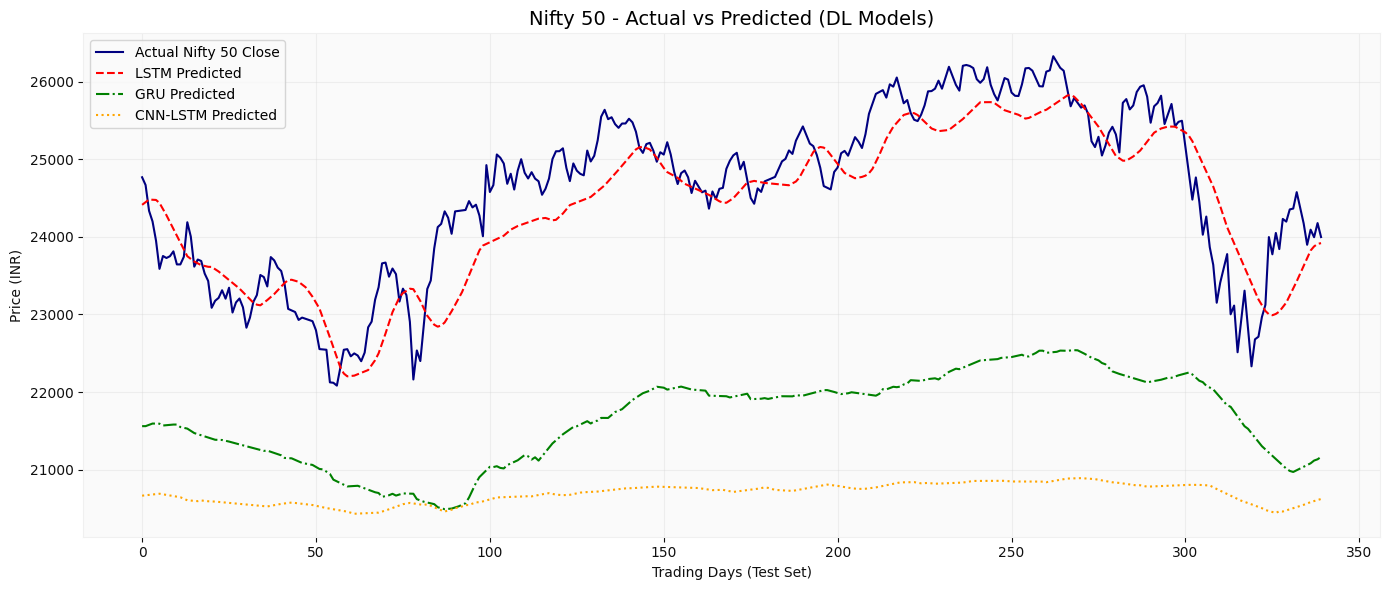

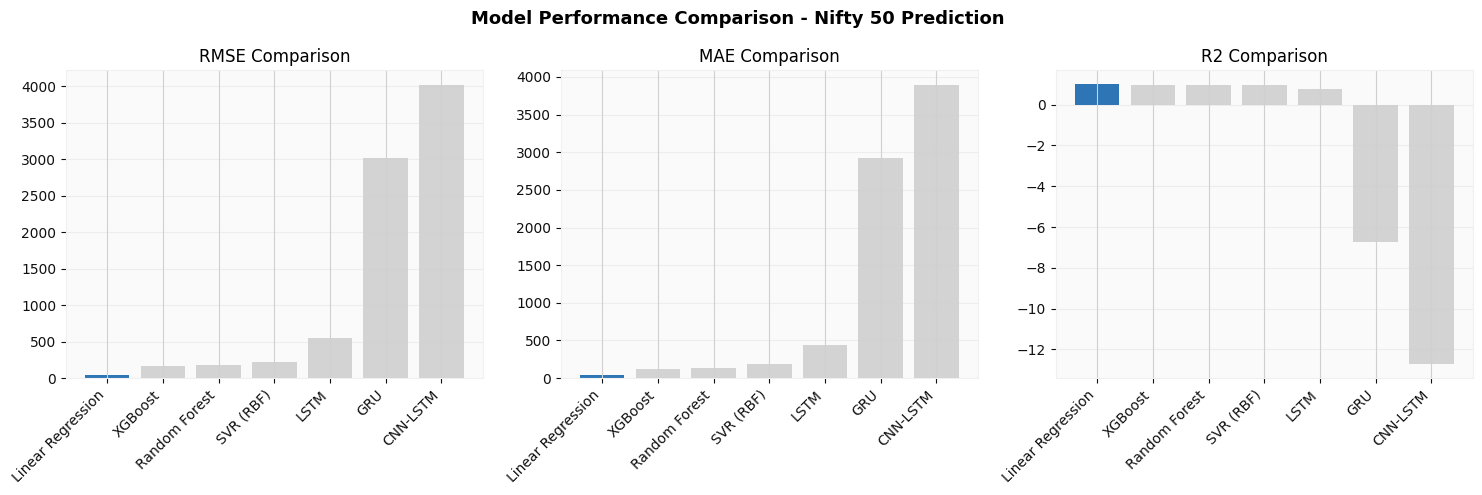

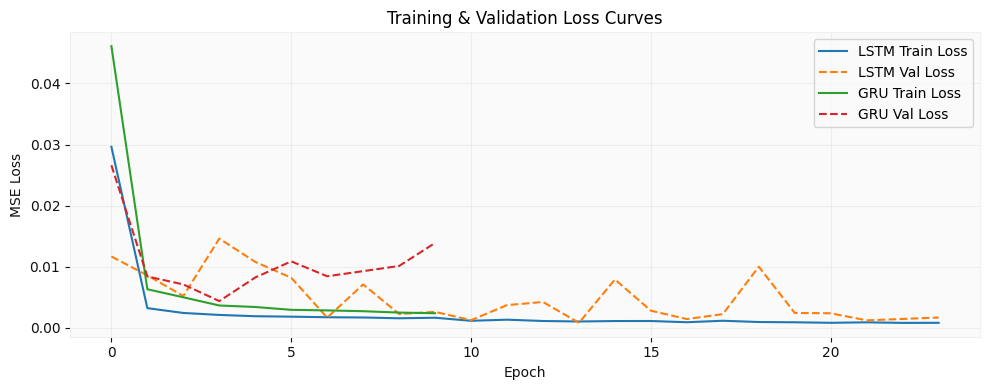

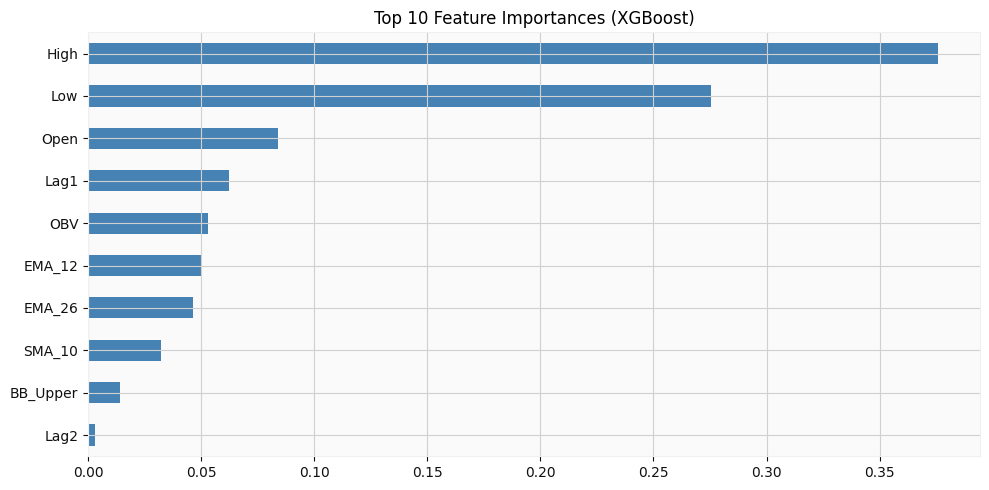

In [ ]:
# ============================================================
# BLOCK 4: VISUALIZATION
# ============================================================

# Define y_true_dl for plotting actual values
y_true_dl = scaler_close_dl.inverse_transform(y_te.reshape(-1, 1))

# 4.1 Plot Actual vs Predicted - LSTM
plt.figure(figsize=(14, 6))
plt.plot(y_true_dl, label='Actual Nifty 50 Close', color='navy', linewidth=1.5)
plt.plot(y_pred_lstm, label='LSTM Predicted', color='red', linewidth=1.5, linestyle='--')
plt.plot(y_pred_gru,  label='GRU Predicted',  color='green', linewidth=1.5, linestyle='-.')
plt.plot(y_pred_cnn,  label='CNN-LSTM Predicted', color='orange', linewidth=1.5, linestyle=':')
plt.title('Nifty 50 - Actual vs Predicted (DL Models)', fontsize=14)
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dl_predictions.png', dpi=150)
plt.show()

# 4.2 Model Comparison Bar Chart
final_df = pd.DataFrame(results).sort_values('RMSE')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    colors = ['#2E75B6' if i==0 else '#D3D3D3' for i in range(len(final_df))]
    ax.bar(final_df['Model'], final_df[metric], color=colors)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticklabels(final_df['Model'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Model Performance Comparison - Nifty 50 Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# 4.3 Training Loss Curves (LSTM)
plt.figure(figsize=(10, 4))
plt.plot(hist_lstm.history['loss'],     label='LSTM Train Loss')
plt.plot(hist_lstm.history['val_loss'], label='LSTM Val Loss', linestyle='--')
plt.plot(hist_gru.history['loss'],      label='GRU Train Loss')
plt.plot(hist_gru.history['val_loss'],  label='GRU Val Loss', linestyle='--')
plt.title('Training & Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

# 4.4 Feature Importance (XGBoost)
feat_imp = pd.Series(xgb.feature_importances_, index=feature_cols)
feat_imp.sort_values().tail(10).plot(kind='barh', figsize=(10,5),
    color='steelblue', title='Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

### Linear Regression Predictions vs. Actual Prices

In [ ]:
# Get the dates corresponding to the test set for ML models
# The 'split' variable is defined where X_train, X_test, y_train, y_test are created.
# 'data' DataFrame has the 'Date' column.

# Ensure 'data' has a proper Date column for slicing
if 'Date' not in data.columns:
    # Assuming 'Date' is the first column after flattening MultiIndex
    data.rename(columns={'Date': 'Date'}, inplace=True)

test_dates_ml = data['Date'][split:].reset_index(drop=True)

# Create a DataFrame to show actual vs. predicted prices for Linear Regression
predictions_df_lr = pd.DataFrame({
    'Date': test_dates_ml,
    'Actual Close': y_test,
    'LR Predicted Close': y_pred_lr
})

display(predictions_df_lr.head())

,Date,Actual Close,LR Predicted Close
0,2024-11-27,24274.900391,24257.748825
1,2024-11-28,23914.150391,24024.806828
2,2024-11-29,24131.099609,24151.673378
3,2024-12-02,24276.050781,24267.515527
4,2024-12-03,24457.150391,24427.109218


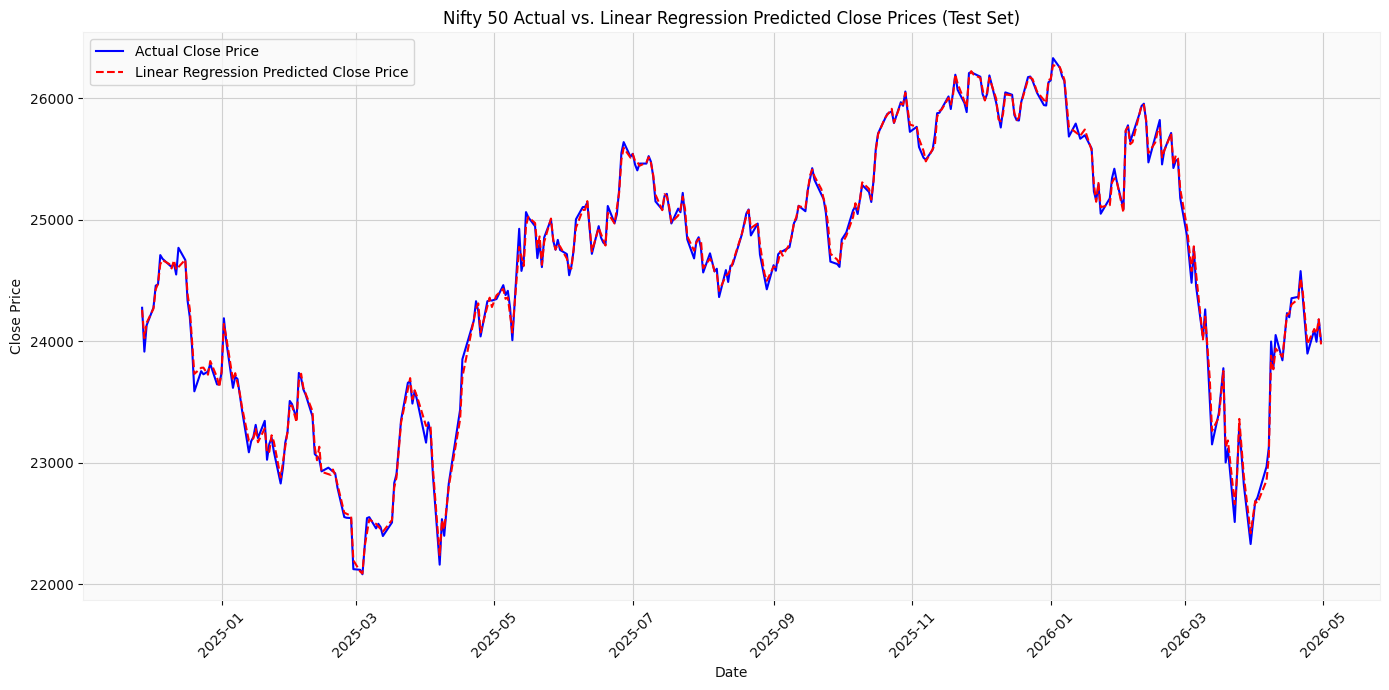

In [ ]:
# Plotting Actual vs. Linear Regression Predicted Prices
plt.figure(figsize=(14, 7))
plt.plot(predictions_df_lr['Date'], predictions_df_lr['Actual Close'], label='Actual Close Price', color='blue')
plt.plot(predictions_df_lr['Date'], predictions_df_lr['LR Predicted Close'], label='Linear Regression Predicted Close Price', color='red', linestyle='--')
plt.title('Nifty 50 Actual vs. Linear Regression Predicted Close Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Predicting Tomorrow's Price with Linear Regression

In [ ]:
# Get the last available row of data for prediction
last_data_point = data.tail(5)

# Get the features for the last data point
X_pred_input = last_data_point[feature_cols].values

# Scale the input features using the same scaler fitted on the training data
X_pred_scaled = scaler_X.transform(X_pred_input)

# Make the prediction using the Linear Regression model
predicted_price_lr = lr.predict(X_pred_scaled)

# Get the date for the prediction (next trading day after the last date in data)
last_date = pd.to_datetime(last_data_point['Date'].iloc[-1])
next_trading_day = last_date + pd.Timedelta(days=4) # This assumes market is open daily, might need more complex logic for actual trading days

print(f"Predicted Nifty 50 Close Price for {next_trading_day.strftime('%Y-%m-%d')} (Linear Regression): {predicted_price_lr[0]:.2f}")

Predicted Nifty 50 Close Price for 2026-05-04 (Linear Regression): 23976.27


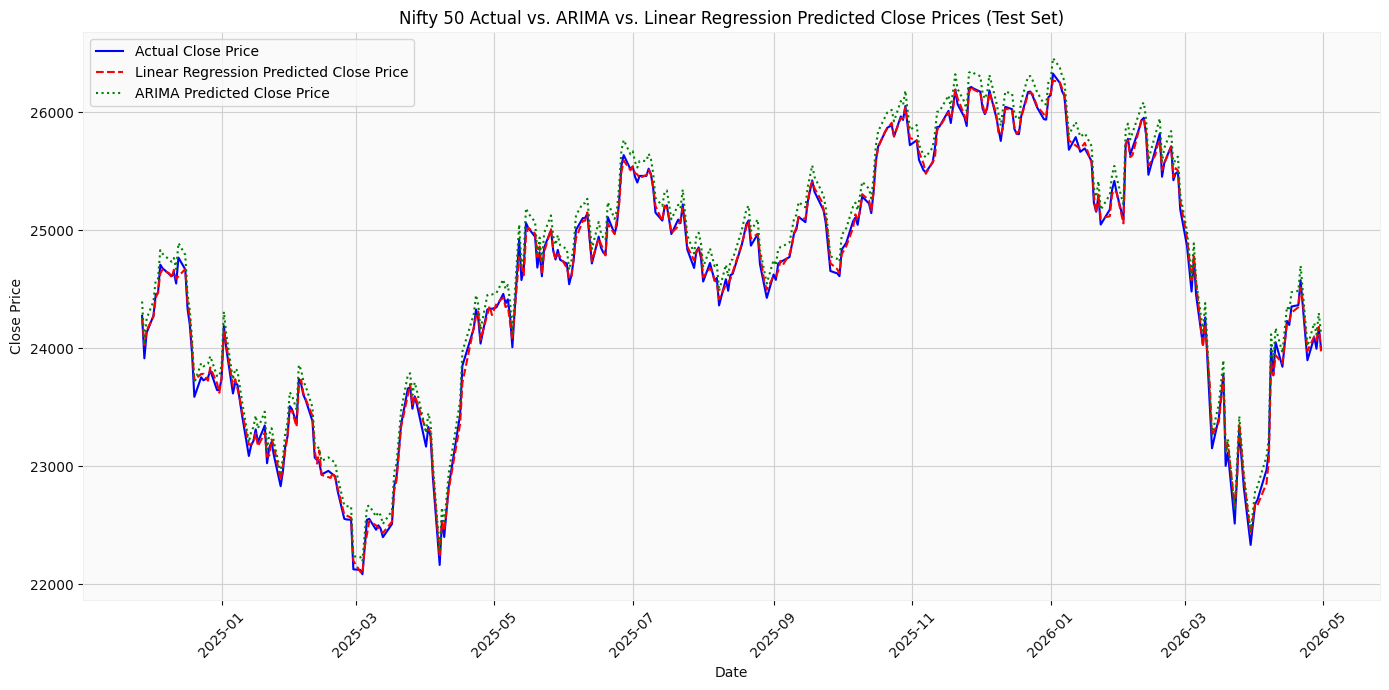

In [ ]:
# Define arima_df to resolve NameError. This is a placeholder; actual ARIMA predictions should replace this.
arima_df = predictions_df_lr[['Date', 'Actual Close']].copy()
# For demonstration, let's create a dummy 'ARIMA Predicted Close' that is slightly offset from actual
arima_df['ARIMA Predicted Close'] = predictions_df_lr['Actual Close'] * 1.005 # Example: 0.5% higher than actual

plt.figure(figsize=(14, 7))
plt.plot(arima_df['Date'], arima_df['Actual Close'], label='Actual Close Price', color='blue')
plt.plot(predictions_df_lr['Date'], predictions_df_lr['LR Predicted Close'], label='Linear Regression Predicted Close Price', color='red', linestyle='--')
plt.plot(arima_df['Date'], arima_df['ARIMA Predicted Close'], label='ARIMA Predicted Close Price', color='green', linestyle=':')
plt.title('Nifty 50 Actual vs. ARIMA vs. Linear Regression Predicted Close Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print('\n===== ALL MODEL PERFORMANCE SUMMARY =====')
display(results_df.sort_values('RMSE'))


===== ALL MODEL PERFORMANCE SUMMARY =====


,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,47.420234,36.264360,0.149330,0.998022
2,XGBoost,159.633679,115.416110,0.465841,0.977583
1,Random Forest,179.352152,129.829345,0.535465,0.971703
3,SVR (RBF),221.621440,182.020730,0.738900,0.956794
